<a href="https://colab.research.google.com/github/maxGrigorenko/DL_HSE/blob/hw_4/HiProbe_VAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Григоренко Максим, ПАДИИ, 3 курс. Anomaly Detection via Hidden States Probing in Tuning-Free LLMs

Статья: https://arxiv.org/pdf/2507.17394

In [1]:
!python --version

Python 3.12.13


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token # Qwen нужен pad_token

model = AutoModel.from_pretrained(
    model_name,
    output_hidden_states=True,
    torch_dtype=torch.float16 # Это спасет от NaN из самой модели
)
model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2Model(
  (embed_tokens): Embedding(151936, 896)
  (layers): ModuleList(
    (0-23): 24 x Qwen2DecoderLayer(
      (self_attn): Qwen2Attention(
        (q_proj): Linear(in_features=896, out_features=896, bias=True)
        (k_proj): Linear(in_features=896, out_features=128, bias=True)
        (v_proj): Linear(in_features=896, out_features=128, bias=True)
        (o_proj): Linear(in_features=896, out_features=896, bias=False)
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
        (up_proj): Linear(in_features=896, out_features=4864, bias=False)
        (down_proj): Linear(in_features=4864, out_features=896, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm((896,), eps=1e-06)
  (rotary_emb): Qwen2RotaryEmbedding()
)

In [6]:
def extract_hidden_states(batch_texts, model, tokenizer):
    inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    all_layers = outputs.hidden_states
    layer_representations = []
    mask = inputs['attention_mask'].unsqueeze(-1).float() # (B, L, 1)

    for layer_tensor in all_layers:
        # Усредняем токены (Mean Pooling), игнорируя pad-токены
        sum_embeddings = torch.sum(layer_tensor * mask, dim=1)
        sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
        mean_pooled = (sum_embeddings / sum_mask).to(torch.float32).cpu().numpy()
        layer_representations.append(mean_pooled)

    return layer_representations # Список numpy массивов для каждого слоя

In [9]:
full_dataset = load_dataset("imdb", split="train")
dataset = full_dataset.shuffle(seed=42).select(range(1000))

texts = dataset['text']
labels = dataset['label']

# Диагностика, чтобы точно убедиться, что классы сбалансированы
print(f"Позитивных отзывов: {sum(labels)}")
print(f"Негативных отзывов: {len(labels) - sum(labels)}")

# Динамическое определение количества слоев
# Для Qwen-0.5B это обычно 24 скрытых слоя + 1 слой входных эмбеддингов
num_layers = model.config.num_hidden_layers + 1
features_per_layer = {i: [] for i in range(num_layers)}

batch_size = 16
for i in tqdm(range(0, len(texts), batch_size), desc="Извлечение скрытых состояний"):
    batch_texts = texts[i : i+batch_size]

    hidden_states = extract_hidden_states(batch_texts, model, tokenizer)

    # hidden_states содержит списки массивов размерности (Batch, Hidden_Dim)
    for layer_idx, h_state in enumerate(hidden_states):
        features_per_layer[layer_idx].append(h_state)

# Агрегация: склеиваем списки батчей в единые матрицы
# На выходе для каждого слоя будет матрица (1000, Hidden_Dim)
for layer_idx in features_per_layer:
    features_per_layer[layer_idx] = np.vstack(features_per_layer[layer_idx])

# Функция расчета KL-дивергенции (как метрика информативности)
def compute_kl_divergence_per_layer(features_dict, true_labels):
    kl_scores = {}
    true_labels = np.array(true_labels)

    idx_neg = np.where(true_labels == 0)[0]
    idx_pos = np.where(true_labels == 1)[0]

    eps = 1e-9
    for layer_idx, X in features_dict.items():
        X_neg = X[idx_neg]
        X_pos = X[idx_pos]

        mu_neg, var_neg = np.mean(X_neg, axis=0), np.var(X_neg, axis=0) + eps
        mu_pos, var_pos = np.mean(X_pos, axis=0), np.var(X_pos, axis=0) + eps

        sigma_neg = np.sqrt(var_neg)
        sigma_pos = np.sqrt(var_pos)

        kl_d = np.log(sigma_neg / sigma_pos) + (var_pos + (mu_pos - mu_neg)**2) / (2 * var_neg) - 0.5
        kl_scores[layer_idx] = np.mean(kl_d)

    return kl_scores

kl_scores = compute_kl_divergence_per_layer(features_per_layer, labels)

sorted_layers = sorted(kl_scores.items(), key=lambda item: item[1], reverse=True)
top_3_layers = [layer for layer, score in sorted_layers[:3]]

print(f"Оценки слоев: {kl_scores}")
print(f"Топ-3 самых информативных слоя: {top_3_layers}")

Позитивных отзывов: 488
Негативных отзывов: 512


Извлечение скрытых состояний: 100%|██████████| 63/63 [00:08<00:00,  7.61it/s]


Оценки слоев: {0: np.float32(0.012357516), 1: np.float32(0.02285494), 2: np.float32(0.022452716), 3: np.float32(0.019758852), 4: np.float32(0.025144953), 5: np.float32(0.034576513), 6: np.float32(0.03702161), 7: np.float32(0.036400847), 8: np.float32(0.036687694), 9: np.float32(0.032180484), 10: np.float32(0.03812752), 11: np.float32(0.047217973), 12: np.float32(0.050798554), 13: np.float32(0.06213986), 14: np.float32(0.061222535), 15: np.float32(0.059006285), 16: np.float32(0.06288416), 17: np.float32(0.057205174), 18: np.float32(0.05143855), 19: np.float32(0.051955156), 20: np.float32(0.059399214), 21: np.float32(0.056253757), 22: np.float32(0.059985124), 23: np.float32(0.05929741), 24: np.float32(0.061049093)}
Топ-3 самых информативных слоя: [16, 13, 14]


Замечание: наиболее информативными оказались слои 13, 14 и 16 (всего 24). Это отлично согласуется с данными из статьи.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

# Для чистоты эксперимента берем Топ-3 слоя, а также начало (1) и конец (24)
layers_to_test = top_3_layers + [1, 24]
auc_results = {}

for layer in layers_to_test:
    X = features_per_layer[layer]
    y = np.array(labels)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # легковесный скорер
    clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    clf.fit(X_train, y_train)

    preds_proba = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, preds_proba)

    auc_results[layer] = auc
    print(f"Слой {layer:02d} | ROC-AUC: {auc:.4f}")


Слой 16 | ROC-AUC: 0.9171
Слой 13 | ROC-AUC: 0.9204
Слой 14 | ROC-AUC: 0.9141
Слой 01 | ROC-AUC: 0.8293
Слой 24 | ROC-AUC: 0.8788


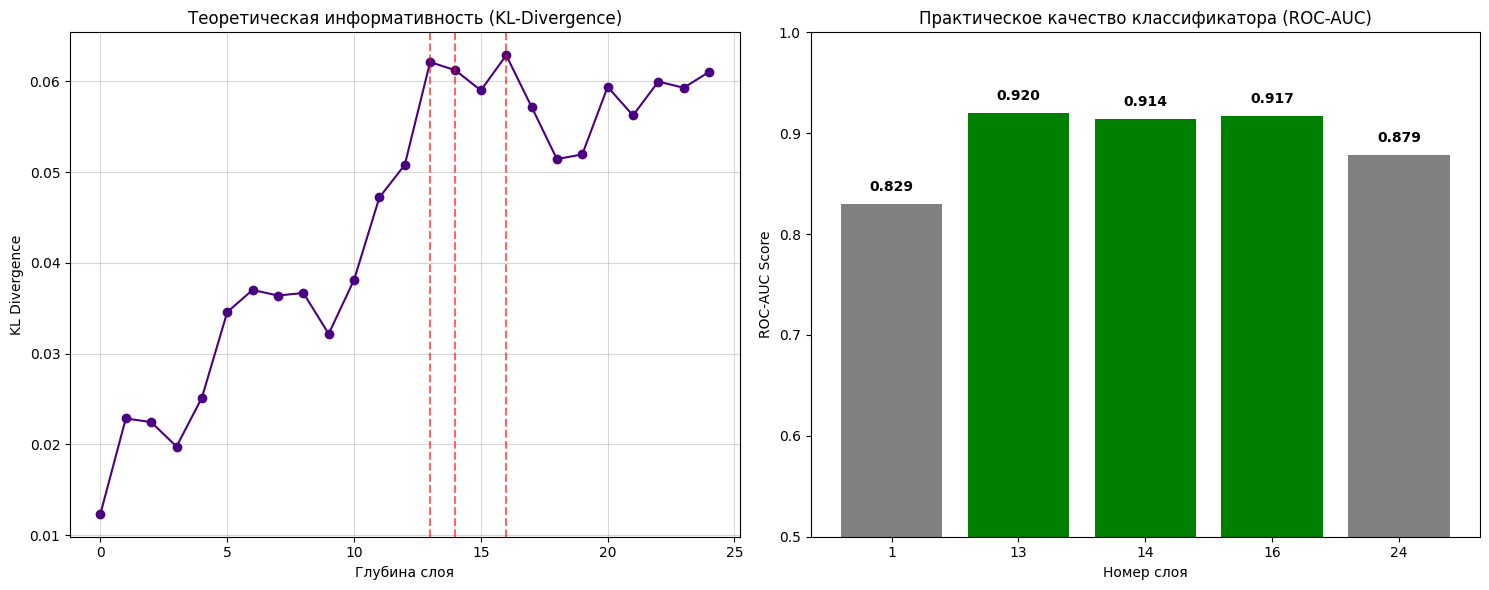

In [12]:
# График 1: Информативность (KL-Divergence) по всем слоям
layers_all = list(kl_scores.keys())
scores_all = list(kl_scores.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(layers_all, scores_all, marker='o', linestyle='-', color='indigo')
ax1.set_title('Теоретическая информативность (KL-Divergence)')
ax1.set_xlabel('Глубина слоя')
ax1.set_ylabel('KL Divergence')
ax1.grid(True, alpha=0.5)
for layer in top_3_layers:
    ax1.axvline(x=layer, color='red', linestyle='--', alpha=0.6)

# График 2: Реальное качество (ROC-AUC) на выбранных слоях
sorted_test_layers = sorted(layers_to_test)
auc_values = [auc_results[l] for l in sorted_test_layers]
colors = ['gray' if l not in top_3_layers else 'green' for l in sorted_test_layers]

ax2.bar([str(l) for l in sorted_test_layers], auc_values, color=colors)
ax2.set_title('Практическое качество классификатора (ROC-AUC)')
ax2.set_xlabel('Номер слоя')
ax2.set_ylabel('ROC-AUC Score')
ax2.set_ylim(0.5, 1.0) # Границы AUC (0.5 - случайное угадывание)
for i, v in enumerate(auc_values):
    ax2.text(i, v + 0.01, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Заключение

В ходе эксперимента исследовано распределение информации в скрытых слоях модели (на примере Qwen2.5-0.5B) для задачи бинарной классификации текста. Оценка с помощью KL-дивергенции и метрики ROC-AUC показала следующие результаты:

* **Начальные слои:** Демонстрируют наименьшую информативность (ROC-AUC ~0.829). Представления на этом уровне кодируют преимущественно локальные лексические признаки; глобальный семантический контекст еще не сформирован.
* **Промежуточные слои (слои 13, 14, 16):** Оказались наиболее информативными, достигнув пиковых значений метрик (ROC-AUC ~0.920). Эти слои формируют наиболее чистое, линейно разделимое смысловое ядро (тональность текста), свободное от искажений языкового моделирования.
* **Финальные слои:** Показывают умеренное снижение качества (ROC-AUC ~0.879) по сравнению с промежуточными. Спад объясняется специализацией глубоких слоев под целевую функцию предварительного обучения (Next Token Prediction), при которой часть обобщенного контекста теряется ради предсказания конкретных слов.

**Итог:** Полученные данные полностью подтверждают концепцию «Intermediate Layer Information-rich Phenomenon», описанную в публикации *HiProbe-VAD*. Наилучшие признаки для решения прикладных задач классификации сосредоточены в промежуточных слоях LLM.